In [1]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [2]:
X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

In [3]:
from sklearn.cluster import KMeans

In [4]:
K=4
kmean=KMeans(
    n_clusters=K,
    random_state=42
)

In [8]:
labels=kmean.fit_predict(X)

<Axes: >

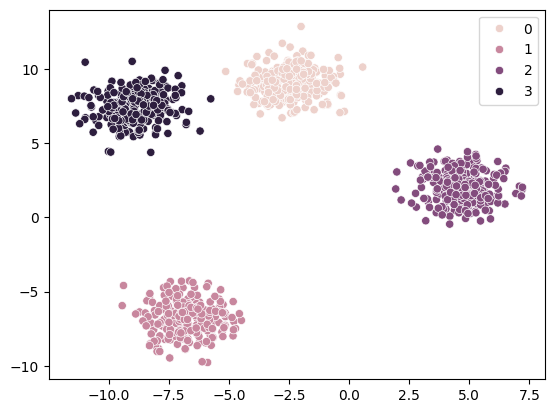

In [9]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels)

# How to choose K-value

## Elbow Method

In [18]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []

k_values = range(1, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

kl = KneeLocator(
    k_values,
    wcss,
    curve="convex",
    direction="decreasing"
)

print("Optimal k:", kl.elbow)

Optimal k: 4


## Silhoutte Score

In [19]:
from sklearn.metrics import silhouette_score
ss = []

k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X) 
    score=silhouette_score(X,labels)
    ss.append(score)

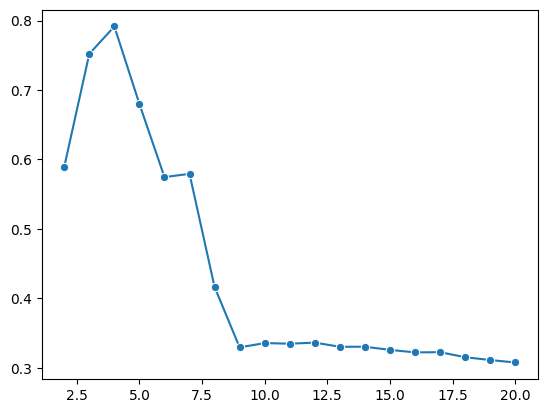

In [21]:
import matplotlib.pyplot as plt
sns.lineplot(x=range(2,21),y=ss,marker='o')
plt.show()

In [25]:
best_k = k_values[list(ss).index(max(ss))]

print("Best K:", best_k)
print("Highest Silhouette Score:", max(ss))

Best K: 4
Highest Silhouette Score: 0.7915983870089952
